In [1]:
import os
import sys
sys.path.insert(0, '../..')
import numpy as np
import matplotlib.pyplot as plt
import mssfp
import deepssfp
import deepssfp.analysis
import deepssfp.dataloader

In [2]:
data_folderpath = 'C:/Users/mmend/projects/mri/data/2017_DeepSSFP/11062017_SSFP_Smoothing_DL_Phantom'
dataset = { 'M': deepssfp.dataloader.load_datasets(data_folderpath, indices=[0, 1, 2, 3]) }
dataset['M'] = dataset['M'][:, 4:-4, :, :]
print(dataset['M'].shape)

Cached data found. Loading...
Dataset loaded: (128, 152, 256, 4)
(128, 144, 256, 4)


In [3]:
from skimage.filters import threshold_li
def create_segmentation_mask(M):
    # Create mask of phantom
    _ = np.sqrt(np.sum(np.abs(M)**2, axis=3))
    _ = abs(_)
    thresh = threshold_li(_)
    mask = np.abs(_) > thresh
    seg = mask * 1
    return seg
seg = create_segmentation_mask(dataset['M'])
dataset['seg'] = seg
print(f"Segmentation shape: {seg.shape}")
print(f"Segmentation values: {np.unique(seg)}")

Segmentation shape: (128, 144, 256)
Segmentation values: [0 1]


In [4]:
modes=['BandRemoval:4', 'BandRemoval:2', 'SuperFOV', 'SyntheticBanding']
model_dir = "D:/DeepSSFP/"
model_name="water_phantom"


===== Running experiment: SuperFOV =====
Model path: D:/DeepSSFP/water_phantom_superfov
Dataset path: D:/DeepSSFP/water_phantom_dataset.npy
Data shape: (128, 144, 256, 4)
Training data shape: (102, 144, 256, 2), (102, 144, 256, 2)
Input scaler stats: mean=0.0000, std=0.0000
Output scaler stats: mean=-0.0000, std=0.0000
Selected indices: [23 17 12]
Figure size: (4, 6)


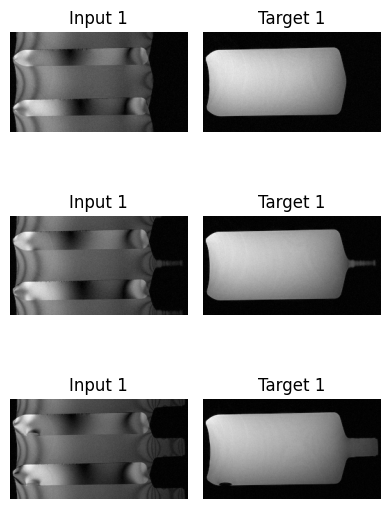

2025-04-03 18:09:58,019 - DeepSSFP - INFO - Loading model from path: D:/DeepSSFP/water_phantom_superfov



Loading pre-trained model...


2025-04-03 18:10:01,958 - DeepSSFP - INFO - Model loaded successfully from D:/DeepSSFP/water_phantom_superfov.keras
2025-04-03 18:10:01,959 - DeepSSFP - INFO - Loading training history from D:/DeepSSFP/water_phantom_superfov_history.npz
2025-04-03 18:10:03,520 - DeepSSFP - INFO - Training history plot saved to D:/DeepSSFP/water_phantom_superfov_training_history.png


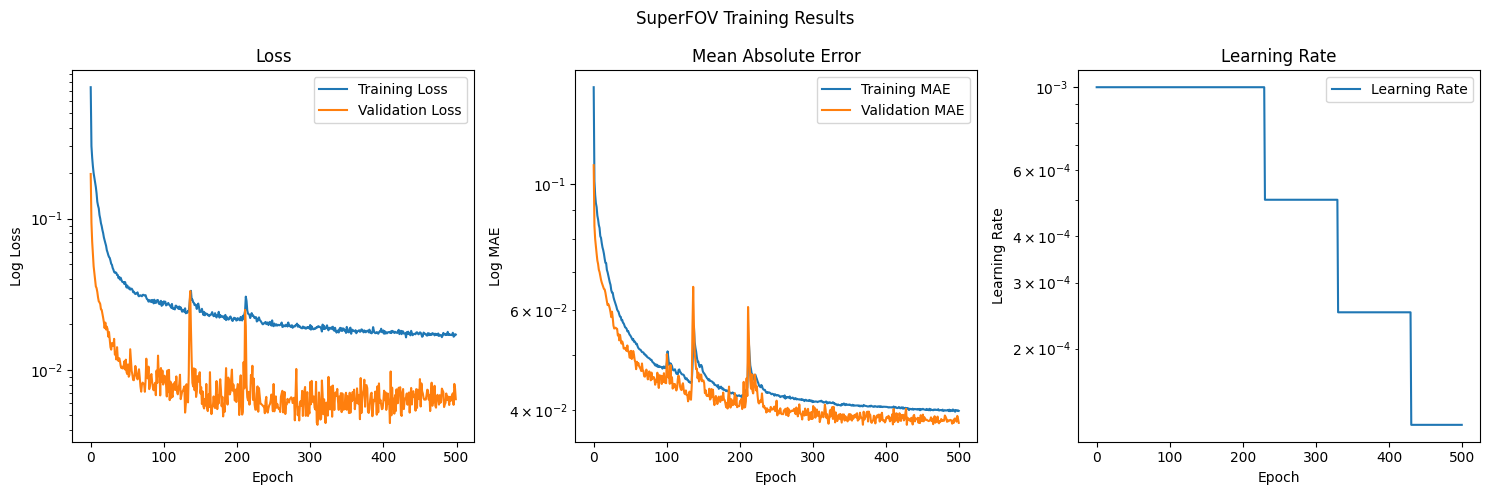

2025-04-03 18:10:22,246 - DeepSSFP - INFO - Making predictions on data with shape (26, 144, 256, 2)
2025-04-03 18:10:27,127 - DeepSSFP - INFO - Predictions complete. Output shape: (26, 144, 256, 2)


Selected indices: [14 13]
Figure size: (6, 4)
Image visualization saved to D:/DeepSSFP/water_phantom_superfov_prediction_results.png


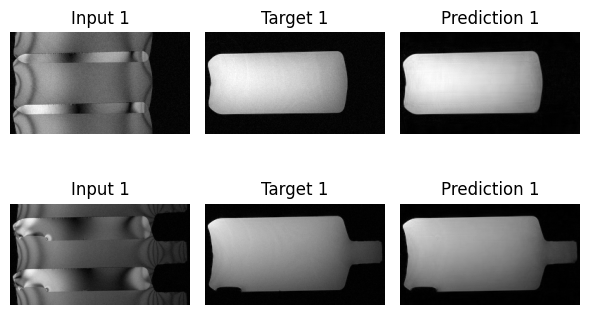

Target shape: (26, 144, 256), Prediction shape: (26, 144, 256)


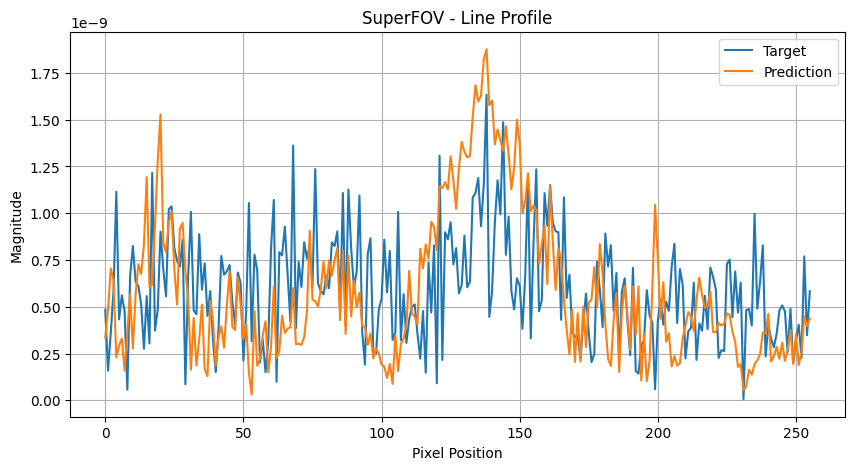


Evaluating band reduction...
Target shape: (26, 144, 256)
Prediction shape: (26, 144, 256)
Segmentation shape: (26, 144, 256)
Unique segmentation IDs: [0 1]
IDs to plot: [1]
Training history plot saved to D:/DeepSSFP/water_phantom_superfov_band_metrics_scatter


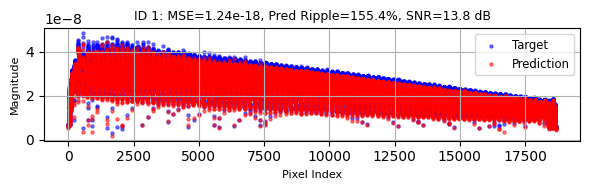

Training history plot saved to D:/DeepSSFP/water_phantom_superfov_band_metrics


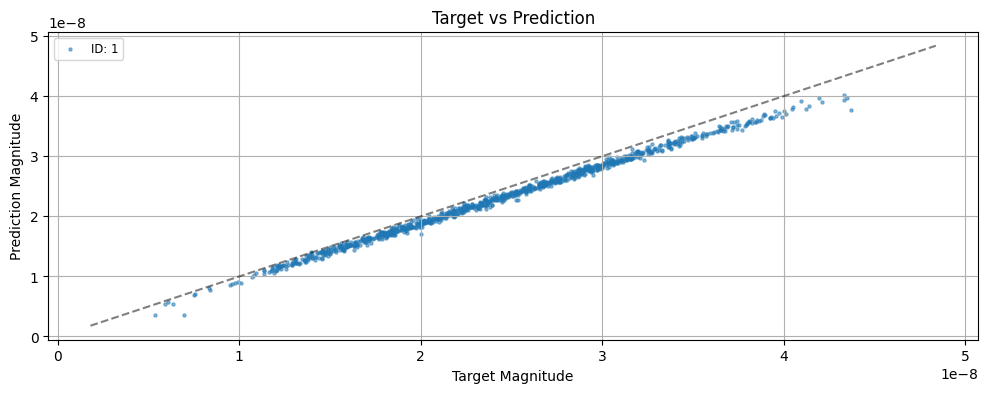


Metrics by Segment ID (averaged across all samples):
ID 1: MSE=1.24e-18, MAE=9.41e-10, Pred Min=0.0000, Pred Max=0.0000, Pred Ripple=155.41%, Pred SNR=13.8 dB, Target Min=0.0000, Target Max=0.0000, Target Ripple=149.91%, Target SNR=13.8 dB, Samples=26, Pixels=18672

Calculating image quality metrics...

===== Image Quality Metrics =====

GLOBAL:
  MSE: 0.000000
  MAE: 0.000000
  PSNR: 182.701838
  SSIM: 1.000000
  NRMSE: 0.082841

SEGMENT_0:
  MSE: 0.000000
  MAE: 0.000000
  PSNR: 188.932240
  SSIM: nan
  NRMSE: 0.535319

SEGMENT_1:
  MSE: 0.000000
  MAE: 0.000000
  PSNR: 179.908552
  SSIM: nan
  NRMSE: 0.065274
Metrics saved to D:/DeepSSFP/water_phantom_superfov_all_metrics.npy


In [5]:
results = deepssfp.analysis.run_experiment(
    mode=deepssfp.DataMode.SuperFOV.value, 
    model_name=model_name,
    model_dir=model_dir,
    train_model=False,
    custom_dataset=dataset
)